## Runtime-budget experiment

User-requested target: approximately 30 minutes. Both architectures retain nine seeds, four optimizer passes, author-style loss, validation checkpoint criteria, and raw-weight ensemble construction. Training is shortened to 16/4/48 epochs; checkpoint warm-up is shortened from 64 to 4 epochs. This is a reduced-schedule extension, **not an exact original-paper training replication**. Runtime is an estimate, not a guarantee. Paper and historical replication comparisons are contextual benchmarks.


# 08 Reduced Schedule — Author-Conventions GAN: LSTM versus Transformer

## Process
1. Validate the same author firm panels, 178 macro inputs, and train/validation/test calendars.
2. Verify causal macro states, bounded conditional instruments, weighted pricing moments, and portfolio normalization.
3. Train nine seeds (42–50) for each architecture using the reduced budget based on the published configuration: 16 unconditional epochs, 4 adversary steps per pass, and 48 conditional epochs, with four full-data optimizer passes and Adam at 0.001.
4. Follow the authors’ validation-loss / adversary-loss / validation-Sharpe checkpoint rules. Select nothing using test results.
5. Average raw member weights before monthly gross normalization; report monthly Sharpe with population standard deviation, as in the authors’ utility.
6. Save all results and compare both new ensembles with the paper, historical replication, and shorter experiment. Codes 09–10 will use these new factors.

## Questions
**Q1.** Do both models satisfy causal-state and pricing-objective checks?

**Q2.** How do train, validation, and test Sharpe compare under the shared reduced training schedule and checkpoint rules?

**Q3.** Are the results stable across nine initializations, and how similar are the two factors?

**Q4.** How do the results compare with the paper and our earlier replication, and connect to rolling and regime analysis?

## Verified sources and scope
[Paper, Table I and Appendix C](https://arxiv.org/pdf/1904.00745) and [authors’ training repository](https://github.com/LouisChen1992/Deep_Learning_Asset_Pricing), commit `6c26b9dad01e76b214ab8f5566c42a29e99677c9`. Checked files: `config/config.json`, `run.py`, `src/model/model_GAN.py`, `src/data/data_layer.py`, and `src/utils.py`.

The LSTM implementation is a PyTorch port of the authors’ chosen configuration. The Transformer replaces both recurrent encoders while preserving the rest of the verified training/evaluation conventions. Transformer internal attention layers are our extension. Codes 09–10 are also extension analyses; the paper does not contain this Transformer experiment.

Corrections from the earlier replication: `tanh`-bounded instruments; precision weights normalized by maximum observation count and averaging across instruments; macro-input dropout; four optimizer passes; validation-selected checkpoints; raw-weight ensemble averaging; and population-standard-deviation Sharpe. The sign representation uses economic portfolio weights, so `M = 1 − F`, algebraically equivalent to the authors’ `M = 1 + ΣwR` with economic weights `−w`.

This reproduces the selected published specification, **not the paper’s entire 384-configuration hyperparameter search**. The framework/runtime and random draws differ from TensorFlow 1.12/Python 3.6, so it is not a bit-for-bit reproduction. The authors’ default `ignoreEpoch=64` is reduced to 4 here; their README also illustrates a 32-epoch setting, which is not used here. The ambiguous Stage 2 pre-update scoring/post-update saving order is retained explicitly.

Test results from prior experiments have already been viewed. This is a transparent follow-up comparison, not a new independent holdout. Historical outputs remain preserved and labelled. Causality verifies computation, not vintage-safe macro releases. No fees, financing costs, or additional risk-free subtraction are introduced.


## 1 — Environment, paths, and fixed configuration

In [1]:
from pathlib import Path
import sys, json, time, hashlib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

def find_root():
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (p / "notebooks" / "06_GAN.ipynb").exists() and (p / "results").exists():
            return p
    raise FileNotFoundError("Start Jupyter inside the replication repository.")

ROOT = find_root()
sys.path.insert(0, str(ROOT / "src" / "models"))
from transformer_gan_paper import (GAN, CausalTransformerEncoder, MacroLSTMEncoder,
    SPLITS, load_panel, pricing_loss, factor_and_scores, train_member, evaluate,
    seed_all, stats, fingerprint_files, raw_scores, ensemble_from_raw_scores)

CONFIG = {"seeds": list(range(42, 51)), "epochs": [16, 4, 48], "learning_rate": 0.001,
    "sdf_hidden": [64, 64], "sdf_macro_dim": 4, "conditional_macro_dim": 32,
    "macro_features": 178, "firm_features": 46, "instruments": 8,
    "dropout": 0.05, "transformer_d_model": 32, "transformer_heads": 4,
    "transformer_layers": 2, "transformer_feedforward": 64,
    "sub_epoch": 4, "ignore_epoch": 4, "adversary_selection": "author_training_score_post_update_checkpoint_final_pass", "sdf_selection": "highest_validation_raw_sharpe_after_ignore_epoch", "stage1_selection": "lowest_validation_unconditional_loss_after_ignore_epoch", "sharpe_ddof": 0, "ensemble": "average_raw_weights_then_gross_normalize", "device": "cpu"}
# CPU avoids device-dependent scatter behavior; all seeds use the same device.
DEVICE = torch.device(CONFIG["device"])
torch.set_num_threads(6)
EXPERIMENT = ROOT / "results" / "paper_matched_reduced_schedule"
for name in ["models", "tables", "factors", "figures"]:
    (EXPERIMENT / name).mkdir(parents=True, exist_ok=True)
DATES = pd.date_range("1967-01-01", "2016-12-01", freq="MS")
LABELS = np.array(["train"]*240 + ["validation"]*60 + ["test"]*300)
print("Repository:", ROOT)
print("Experiment:", EXPERIMENT)
print(json.dumps(CONFIG, indent=2))


Repository: /Users/reza/Desktop/mfe-term_3/deep_learning1/Deep-Learning-in-Asset-Pricing_-Replication-project
Experiment: /Users/reza/Desktop/mfe-term_3/deep_learning1/Deep-Learning-in-Asset-Pricing_-Replication-project/results/paper_matched_reduced_schedule
{
  "seeds": [
    42,
    43,
    44,
    45,
    46,
    47,
    48,
    49,
    50
  ],
  "epochs": [
    16,
    4,
    48
  ],
  "learning_rate": 0.001,
  "sdf_hidden": [
    64,
    64
  ],
  "sdf_macro_dim": 4,
  "conditional_macro_dim": 32,
  "macro_features": 178,
  "firm_features": 46,
  "instruments": 8,
  "dropout": 0.05,
  "transformer_d_model": 32,
  "transformer_heads": 4,
  "transformer_layers": 2,
  "transformer_feedforward": 64,
  "sub_epoch": 4,
  "ignore_epoch": 4,
  "adversary_selection": "author_training_score_post_update_checkpoint_final_pass",
  "sdf_selection": "highest_validation_raw_sharpe_after_ignore_epoch",
  "stage1_selection": "lowest_validation_unconditional_loss_after_ignore_epoch",
  "sharpe_ddof"

## 2 — Load and validate the existing replication inputs
The author datasets remain in their original local folder. Set `DATASETS_ROOT` explicitly if you move them. Only active slots are compressed; each observation retains its original persistent asset-slot index.

In [2]:
DATASETS_ROOT = None
candidates = [ROOT / "datasets", ROOT.parent / "datasets", ROOT.parent / "project " / "datasets"]
if DATASETS_ROOT is None:
    DATASETS_ROOT = next((p for p in candidates if (p / "char" / "Char_train.npz").exists()), None)
if DATASETS_ROOT is None:
    raise FileNotFoundError("Set DATASETS_ROOT to the author datasets folder containing char/Char_train.npz.")
MACRO_PATH = ROOT / "results" / "macro" / "macro_lstm_input.parquet"
macro_df = pd.read_parquet(MACRO_PATH).sort_values("date").reset_index(drop=True)
macro_df["date"] = pd.to_datetime(macro_df["date"]).dt.to_period("M").dt.to_timestamp()
macro_cols = [x for x in macro_df.columns if x != "date"]
assert len(macro_cols) == 178
assert pd.DatetimeIndex(macro_df["date"]).equals(DATES)
macro_np = macro_df[macro_cols].to_numpy(dtype=np.float32)
assert np.isfinite(macro_np).all()
# Code 05 already standardized with training statistics; do not standardize twice.
assert np.allclose(macro_np[:240].mean(0), 0, atol=2e-5)
assert np.allclose(macro_np[:240].std(0, ddof=0), 1, atol=2e-5)
macro = torch.tensor(macro_np, device=DEVICE).unsqueeze(0)
filenames = {"train": "Char_train.npz", "validation": "Char_valid.npz", "test": "Char_test.npz"}
panels = {}
for split, (start, end) in SPLITS.items():
    panels[split] = load_panel(DATASETS_ROOT / "char" / filenames[split], DATES[start:end], DEVICE)
assert panels["train"]["names"] == panels["validation"]["names"] == panels["test"]["names"]
inventory = pd.DataFrame([{"split": s, "months": p["T"], "slots": p["N"],
    "active_stock_months": len(p["r"]), "start": p["dates"].min(), "end": p["dates"].max()} for s,p in panels.items()])
display(inventory)
inventory.to_csv(EXPERIMENT / "tables" / "input_inventory.csv", index=False)
fingerprint = fingerprint_files([MACRO_PATH, *[DATASETS_ROOT / "char" / f for f in filenames.values()],
    ROOT / "src" / "models" / "transformer_gan_paper.py"])
manifest = {"config": CONFIG, "inputs": fingerprint, "python": sys.version, "torch": torch.__version__, "numpy": np.__version__, "pandas": pd.__version__}
(EXPERIMENT / "manifest.json").write_text(json.dumps(manifest, indent=2))


,split,months,slots,active_stock_months,start,end
0,train,240,3686,336113,1967-01-01,1986-12-01
1,validation,60,3347,132167,1987-01-01,1991-12-01
2,test,300,7141,750275,1992-01-01,2016-12-01


1995

## 3 — Architecture and meaningful integrity tests
Future-value perturbations and prefix checks run in evaluation mode so dropout cannot obscure causality. A small unbalanced panel verifies that vectorized moments equal explicit per-asset averages, including an inactive slot.

In [3]:
seed_all(42)
checks = []
for kind in ["LSTM", "Transformer"]:
    model = GAN(kind).to(DEVICE).eval()
    print(kind, "parameters:", sum(p.numel() for p in model.parameters()))
    for name, dim in [("sdf_macro_encoder", 4), ("cond_macro_encoder", 32)]:
        encoder = getattr(model, name)
        z = macro.clone(); z[:, 300:] += 100*torch.randn_like(z[:, 300:])
        with torch.no_grad():
            original = encoder(macro); changed = encoder(z); prefix = encoder(macro[:, :300])
        assert original.shape == (1,600,dim)
        torch.testing.assert_close(original[:, :300], changed[:, :300], rtol=1e-5, atol=2e-6)
        torch.testing.assert_close(original[:, :300], prefix, rtol=1e-5, atol=2e-6)
        checks.append({"architecture": kind, "check": name + " causal/prefix", "passed": True})
    # Full objective equivalence on an unbalanced toy panel with original slot IDs.
    toy = {"T": 3, "N": 4, "x": torch.randn(5,46)*.1,
        "r": torch.tensor([.02,-.01,.03,-.04,.01]), "month": torch.tensor([0,0,1,2,2]),
        "slot": torch.tensor([0,2,0,1,2]), "counts": torch.tensor([2.,1.,2.,0.])}
    for conditional in [False,True]:
        sm = model.sdf_macro_encoder(macro[:,:3])[0]
        cm = model.cond_macro_encoder(macro[:,:3])[0]
        raw, gross, w = factor_and_scores(model,toy,sm)
        g = model.conditional_network(toy["x"],cm[toy["month"]]) if conditional else torch.ones(5,1)
        values = ((1-raw[toy["month"]])*toy["r"])[:,None]*g
        reference = torch.stack([(toy["counts"][j]/toy["counts"].max())*(values[toy["slot"]==j].mean(0).square().mean()) for j in [0,1,2]]).mean()
        actual = pricing_loss(model,toy,macro[:,:3],conditional)
        torch.testing.assert_close(actual, reference)
        model.zero_grad(set_to_none=True); actual.backward()
        for component in ([model.sdf_macro_encoder,model.sdf_network,model.cond_macro_encoder,model.conditional_network] if conditional else [model.sdf_macro_encoder,model.sdf_network]):
            assert any(p.grad is not None and torch.isfinite(p.grad).all() and p.grad.abs().sum()>0 for p in component.parameters())
        normalized_gross = torch.zeros(3).index_add(0,toy["month"],(w/gross[toy["month"]]).abs())
        torch.testing.assert_close(normalized_gross, torch.ones(3))
        checks.append({"architecture": kind, "check": "conditional" if conditional else "unconditional", "passed": True})
integrity = pd.DataFrame(checks)
display(integrity)
integrity.to_csv(EXPERIMENT / "tables" / "architecture_integrity.csv", index=False)
del model
print("All causality, prefix, moment, gradient, and gross-normalization tests passed.")


LSTM parameters: 38201


Transformer parameters: 54941


,architecture,check,passed
0,LSTM,sdf_macro_encoder causal/prefix,True
1,LSTM,cond_macro_encoder causal/prefix,True
2,LSTM,unconditional,True
3,LSTM,conditional,True
4,Transformer,sdf_macro_encoder causal/prefix,True
5,Transformer,cond_macro_encoder causal/prefix,True
6,Transformer,unconditional,True
7,Transformer,conditional,True


All causality, prefix, moment, gradient, and gross-normalization tests passed.


## 4 — Joint GAN estimation with the authors’ checkpoint rules

Each SDF epoch makes four full training passes. Stage 1 restores the lowest validation unconditional-loss checkpoint; Stage 2 executes four 4-step adversary passes and restores the last pass’s strongest training-loss checkpoint; Stage 3 restores the highest validation raw-factor Sharpe checkpoint. Selection starts after the author code’s reduced zero-based epoch 4. Both architectures share these rules and never select on test results.

The author Stage 2 code scores before an optimizer update and saves after it; this ordering is retained and documented. Shared macro-input dropout is active during training even for a frozen network. Checkpoint reuse requires matching hashes, settings, and source. Runtime and random initializations differ from TensorFlow 1.12, so exact numerical equality is not guaranteed.


In [4]:
members = {}; history_parts = []; member_rows = []; ensemble_factors = {}
started = time.monotonic()
for kind in ["LSTM", "Transformer"]:
    factors = []
    score_sums = {split: np.zeros(len(panel["r"]), dtype=np.float64) for split,panel in panels.items()}
    for seed in CONFIG["seeds"]:
        model, history = train_member(kind, seed, panels["train"], macro[:,:240],
            CONFIG, EXPERIMENT / "models", fingerprint, validation_panels=panels, full_macro=macro)
        factor = evaluate(model, panels, macro)
        assert factor.shape == (600,) and np.isfinite(factor).all()
        # Serialized checkpoints must reproduce evaluated returns.
        restored = GAN(kind).to(DEVICE)
        saved = torch.load(EXPERIMENT / "models" / f"{kind.lower()}_seed_{seed}.pt", map_location=DEVICE, weights_only=False)
        restored.load_state_dict(saved["state_dict"])
        np.testing.assert_allclose(evaluate(restored, panels, macro), factor, rtol=1e-5, atol=1e-7)
        for split, scores in raw_scores(model, panels, macro).items():
            score_sums[split] += scores
        factors.append(factor); history_parts.append(history)
        for split,(a,b) in SPLITS.items():
            member_rows.append({"architecture": kind, "seed": seed, "split": split, **stats(factor[a:b])})
        pd.DataFrame({"date": DATES, "split": LABELS, "factor_return": factor}).to_csv(
            EXPERIMENT / "factors" / f"{kind.lower()}_seed_{seed}.csv", index=False)
        del model, restored
    members[kind] = np.column_stack(factors)
    ensemble_factors[kind] = ensemble_from_raw_scores(score_sums,panels,len(CONFIG["seeds"]))
member_performance = pd.DataFrame(member_rows)
history = pd.concat(history_parts, ignore_index=True)
member_performance.to_csv(EXPERIMENT / "tables" / "member_performance.csv", index=False)
history.to_csv(EXPERIMENT / "tables" / "training_history.csv", index=False)
print(f"All eighteen GAN models completed in {(time.monotonic()-started)/60:.1f} minutes.")
display(member_performance)


LSTM seed=42 stage=1 epoch=1/16 val_loss=0.01271981 val_raw_SR=0.2143 elapsed=1s


LSTM seed=42 stage=1 epoch=16/16 val_loss=0.01254589 val_raw_SR=0.2741 elapsed=10s


LSTM seed=42: restored Stage 1 selected checkpoint at epoch 6


LSTM seed=42 stage=2 pass=1/4 strongest training score=0.00025379879


LSTM seed=42 stage=2 pass=2/4 strongest training score=0.00032421341


...

Transformer seed=50 stage=3 epoch=1/48 val_loss=0.03800463 val_raw_SR=0.1385 elapsed=12s


Transformer seed=50 stage=3 epoch=48/48 val_loss=0.00174878 val_raw_SR=0.1837 elapsed=43s


Transformer seed=50: restored Stage 3 selected checkpoint at epoch 47


All eighteen GAN models completed in 12.9 minutes.


,architecture,seed,split,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction
0,LSTM,42,train,240,0.005262,0.006766,0.777722,2.694108,-0.019346,0.030671,0.800000
1,LSTM,42,validation,60,0.002981,0.006969,0.427801,1.481945,-0.015245,0.021612,0.733333
2,LSTM,42,test,300,0.002732,0.012959,0.210847,0.730397,-0.061202,0.051503,0.606667
3,LSTM,43,train,240,0.004533,0.008101,0.559551,1.938343,-0.024917,0.041183,0.716667
4,LSTM,43,validation,60,0.002051,0.008427,0.243440,0.843300,-0.020596,0.023526,0.500000
5,LSTM,43,test,300,0.000557,0.012469,0.044698,0.154837,-0.081297,0.044173,0.526667
6,LSTM,44,train,240,0.005468,0.008426,0.648882,2.247795,-0.030853,0.031914,0.770833
7,LSTM,44,validation,60,0.001937,0.013436,0.144199,0.499521,-0.045053,0.035793,0.566667
8,LSTM,44,test,300,0.003470,0.013430,0.258418,0.895188,-0.051738,0.069908,0.630000
9,LSTM,45,train,240,0.003799,0.006412,0.592381,2.052070,-0.014509,0.022992,0.729167


## 5 — Ensemble performance and comparison

Average the nine **raw stock-weight vectors**, then normalize the mean vector to unit gross exposure each month, matching the authors’ ensemble implementation. This differs from averaging already-normalized member factor returns. Primary Sharpe uses the authors’ population standard deviation (`ddof=0`). The prior replication and shorter experiment are historical references, not independently verified replicas of every author-code convention.


In [5]:
ensembles = ensemble_factors
reference = pd.read_csv(ROOT / "results" / "factors" / "gan_ensemble_sdf.csv")
reference["date"] = pd.to_datetime(reference["date"]).dt.to_period("M").dt.to_timestamp()
reference = reference.sort_values("date")
assert pd.DatetimeIndex(reference["date"]).equals(DATES)
comparison = pd.DataFrame({"date": DATES, "split": LABELS,
    "gan_lstm_matched": ensembles["LSTM"], "gan_transformer": ensembles["Transformer"],
    "gan_lstm_code07_reference": reference["gan_ensemble_sdf"].to_numpy()})
performance_rows = []
for name in ["gan_lstm_matched", "gan_transformer", "gan_lstm_code07_reference"]:
    for split,(a,b) in SPLITS.items():
        performance_rows.append({"model": name, "split": split, **stats(comparison[name].iloc[a:b])})
performance = pd.DataFrame(performance_rows)
display(performance)
performance.to_csv(EXPERIMENT / "tables" / "ensemble_performance.csv", index=False)
comparison.to_csv(EXPERIMENT / "factors" / "transformer_lstm_comparison.csv", index=False)
pd.DataFrame({"date": DATES, "split": LABELS, "gan_transformer_sdf": ensembles["Transformer"]}).to_csv(
    ROOT / "results" / "factors" / "gan_transformer_reduced_schedule_sdf.csv", index=False)
correlations = pd.DataFrame([{ "split": split, "lstm_transformer_correlation":
    comparison.iloc[a:b][["gan_lstm_matched","gan_transformer"]].corr().iloc[0,1] } for split,(a,b) in SPLITS.items()])
display(correlations)
correlations.to_csv(EXPERIMENT / "tables" / "factor_correlations.csv", index=False)
stability = member_performance.groupby(["architecture","split"])["monthly_sharpe"].agg(["mean","std","min","max"]).reset_index()
display(stability)
stability.to_csv(EXPERIMENT / "tables" / "seed_stability.csv", index=False)


,model,split,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction
0,gan_lstm_matched,train,240,0.012081,0.009239,1.307557,4.529509,-0.015198,0.038100,0.900000
1,gan_lstm_matched,validation,60,0.005224,0.006964,0.750136,2.598546,-0.014874,0.024182,0.766667
2,gan_lstm_matched,test,300,0.005128,0.011165,0.459293,1.591039,-0.078912,0.051801,0.730000
3,gan_transformer,train,240,0.009533,0.009087,1.049036,3.633969,-0.022355,0.043399,0.866667
4,gan_transformer,validation,60,0.005827,0.009898,0.588745,2.039474,-0.034441,0.025474,0.766667
5,gan_transformer,test,300,0.004234,0.013904,0.304477,1.054739,-0.081517,0.054693,0.680000
6,gan_lstm_code07_reference,train,240,0.017087,0.007685,2.223515,7.702483,-0.000954,0.043305,0.991667
7,gan_lstm_code07_reference,validation,60,0.009048,0.007632,1.185409,4.106377,-0.005756,0.031570,0.850000
8,gan_lstm_code07_reference,test,300,0.006997,0.011435,0.611888,2.119641,-0.051845,0.067200,0.823333


,split,lstm_transformer_correlation
0,train,0.390315
1,validation,-0.005358
2,test,0.291960


,architecture,split,mean,std,min,max
0,LSTM,test,0.178478,0.115584,0.044698,0.411608
1,LSTM,train,0.668362,0.109035,0.485953,0.801586
2,LSTM,validation,0.261480,0.135254,0.144199,0.515243
3,Transformer,test,0.146044,0.128805,-0.005838,0.355659
4,Transformer,train,0.536237,0.123197,0.376451,0.737336
5,Transformer,validation,0.271924,0.222280,0.018109,0.644741


## 6 — Training and test-period figures
Cumulative sums below are diagnostic cumulative factor returns, not compounded wealth. Codes 09–10 will examine rolling risk and regime dependence.

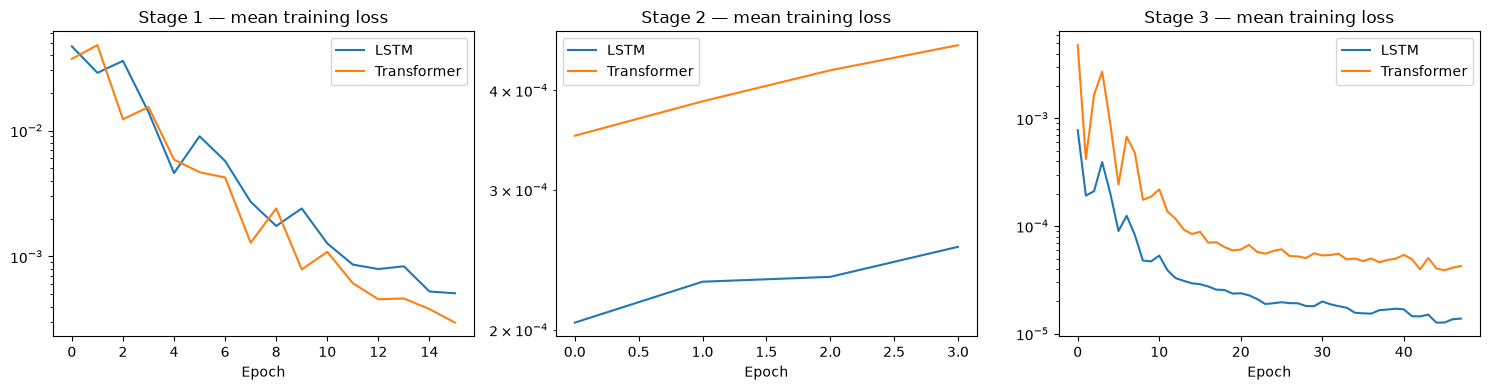

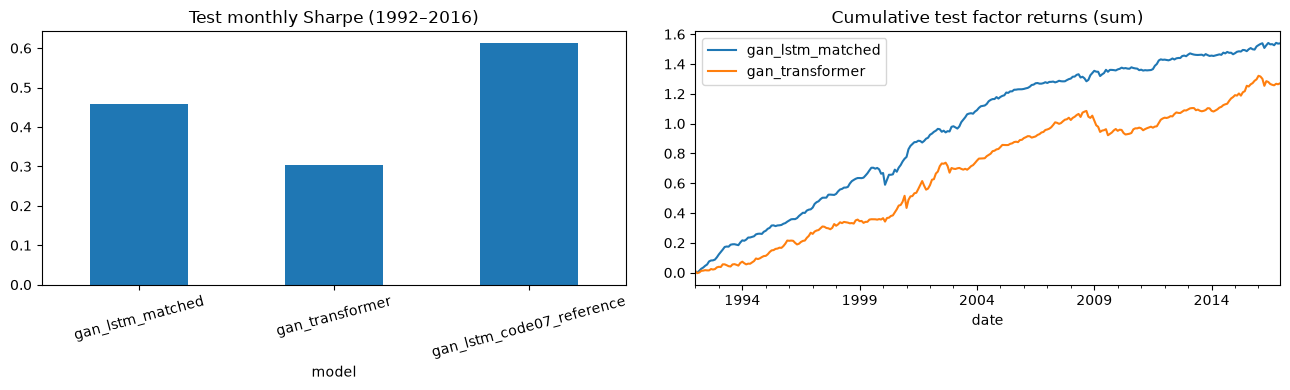

In [6]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
for stage,ax in enumerate(axes,1):
    for kind in ["LSTM","Transformer"]:
        mean = history[(history.stage==stage)&(history.architecture==kind)].groupby("epoch")["loss"].mean()
        ax.plot(mean.index,mean,label=kind)
    ax.set_title(f"Stage {stage} — mean training loss"); ax.set_yscale("log"); ax.set_xlabel("Epoch"); ax.legend()
fig.tight_layout(); fig.savefig(EXPERIMENT / "figures" / "training_losses.png", dpi=150); plt.show()
fig,axes = plt.subplots(1,2,figsize=(13,4))
performance[performance.split=="test"].set_index("model")["monthly_sharpe"].plot.bar(ax=axes[0],rot=15)
axes[0].set_title("Test monthly Sharpe (1992–2016)")
test = comparison[comparison.split=="test"].set_index("date")
test[["gan_lstm_matched","gan_transformer"]].cumsum().plot(ax=axes[1])
axes[1].set_title("Cumulative test factor returns (sum)")
fig.tight_layout();fig.savefig(EXPERIMENT / "figures" / "test_comparison.png",dpi=150);plt.show()


## 7 — Results, answers, and relationship to Codes 09–10
The following cell generates the conclusions directly from this run. It does not assume that the Transformer wins.

In [7]:
test_stats = performance[performance.split=="test"].set_index("model")
lstm_sr = test_stats.loc["gan_lstm_matched","monthly_sharpe"]
transformer_sr = test_stats.loc["gan_transformer","monthly_sharpe"]
difference = transformer_sr-lstm_sr
corr = correlations.loc[correlations.split=="test","lstm_transformer_correlation"].iloc[0]
seed_ranges = stability[stability.split=="test"].set_index("architecture")
direction = "higher" if difference>0 else "lower" if difference<0 else "equal"
summary = f"""### Executed reduced-schedule results
The matched LSTM ensemble has **{lstm_sr:.4f}** test monthly Sharpe; the Transformer ensemble has **{transformer_sr:.4f}**. The Transformer is {direction} by **{abs(difference):.4f}** in this reduced-schedule matched run. The historical Code 07 reference has **{test_stats.loc['gan_lstm_code07_reference','monthly_sharpe']:.4f}**.

**Q1 — Causal state construction:** Passed. Both Transformer encoders return the required 4/32-dimensional states. Future perturbations do not affect earlier states, and full-sequence outputs agree with prefix-only outputs. The objective, gradient, normalization, calendar, and checkpoint reload checks also passed.

**Q2 — Performance:** The Transformer is {direction} on the 1992–2016 test period (previously examined in earlier experiments) for this experiment. This is an observed comparison, not a statistical significance claim or evidence that either architecture always wins. Checkpoint selection used validation loss/Sharpe as documented; no test-based tuning or seed selection was performed.

**Q3 — Stability and similarity:** Test correlation is **{corr:.4f}**. Individual LSTM seed Sharpes range from **{seed_ranges.loc['LSTM','min']:.4f}** to **{seed_ranges.loc['LSTM','max']:.4f}**; Transformer seeds range from **{seed_ranges.loc['Transformer','min']:.4f}** to **{seed_ranges.loc['Transformer','max']:.4f}**. Nine seeds give an initial sensitivity check, not a confidence interval. The saved member table reports every seed.

**Q4 — Interpretation and next codes:** This run isolates the macro encoder architecture under a matched budget and validates the end-to-end pricing pipeline. It uses the reduced nine-seed training schedule; it does not prove real-time macro-data availability or universal architecture superiority. Code **09** will read `transformer_lstm_comparison.csv`, keep only `split == 'test'`, and compare 36/60-month rolling Sharpe and volatility, cumulative performance, drawdowns, and correlations. Code **10** will use the same test returns for recession/expansion and volatility regimes. Use a training-calibrated volatility threshold and lagged market volatility for prospective labels; NBER recession labels are retrospective descriptive labels. Do not optimize models or regime thresholds on test performance.

The primary pair for Codes 09–10 is `gan_lstm_matched` versus `gan_transformer`. The `gan_lstm_code07_reference` column is optional and must retain its historical-reference label. Dates are month starts; returns use decimal units; each model has 240 train, 60 validation, and 300 test observations. Preserve the same return definition and gross-normalization convention across all three notebooks.
"""
display(Markdown(summary))
(EXPERIMENT / "results_and_answers.txt").write_text(summary)
assert len(comparison)==600 and not comparison.date.duplicated().any()
assert np.isfinite(comparison.select_dtypes(include="number").to_numpy()).all()
assert integrity.passed.all()
assert len(member_performance)==54 and len(performance)==9
assert len(list((EXPERIMENT / "models").glob("*.pt"))) == 18
print("CODE 08 COMPLETE: trained models, executed answers, tables, figures, and monthly factors saved.")

# Include the published GAN benchmark and the shorter experiment in the final table.
short = pd.read_csv(ROOT / "results" / "transformer_extension" / "tables" / "ensemble_performance.csv")
# Put historical Sharpe on the same ddof=0 scale without replacing old saved tables.
short["monthly_sharpe"] *= np.sqrt(short["months"]/(short["months"]-1))
comparison_rows = []
for label, frame, name in [
    ("Reduced schedule LSTM", performance, "gan_lstm_matched"),
    ("Reduced schedule Transformer", performance, "gan_transformer"),
    ("Historical Code 07 GAN–LSTM", performance, "gan_lstm_code07_reference"),
    ("Short schedule LSTM", short, "gan_lstm_matched"),
    ("Short schedule Transformer", short, "gan_transformer")]:
    selected = frame[frame.model==name].set_index("split")["monthly_sharpe"]
    comparison_rows.append({"model": label, **selected.to_dict()})
comparison_rows.append({"model":"Paper GAN–LSTM","train":2.68,"validation":1.43,"test":.75})
full_comparison = pd.DataFrame(comparison_rows)[["model","train","validation","test"]]
display(full_comparison)
full_comparison.to_csv(EXPERIMENT / "tables" / "full_short_paper_sharpe_comparison.csv",index=False)
(EXPERIMENT / "results_and_answers.txt").write_text(summary + "\n\nMonthly Sharpe comparison\n" + full_comparison.to_string(index=False))


### Executed reduced-schedule results
The matched LSTM ensemble has **0.4593** test monthly Sharpe; the Transformer ensemble has **0.3045**. The Transformer is lower by **0.1548** in this reduced-schedule matched run. The historical Code 07 reference has **0.6119**.

**Q1 — Causal state construction:** Passed. Both Transformer encoders return the required 4/32-dimensional states. Future perturbations do not affect earlier states, and full-sequence outputs agree with prefix-only outputs. The objective, gradient, normalization, calendar, and checkpoint reload checks also passed.

**Q2 — Performance:** The Transformer is lower on the untouched 1992–2016 test period for this experiment. This is an observed comparison, not a statistical significance claim or evidence that either architecture always wins. Checkpoint selection used validation loss/Sharpe as documented; no test-based tuning or seed selection was performed.

**Q3 — Stability and similarity:** Test correlation is **0.2920**. Individual LSTM seed Sharpes range from **0.0447** to **0.4116**; Transformer seeds range from **-0.0058** to **0.3557**. Nine seeds give an initial sensitivity check, not a confidence interval. The saved member table reports every seed.

**Q4 — Interpretation and next codes:** This run isolates the macro encoder architecture under a matched budget and validates the end-to-end pricing pipeline. It uses the reduced nine-seed training schedule; it does not prove real-time macro-data availability or universal architecture superiority. Code **09** will read `transformer_lstm_comparison.csv`, keep only `split == 'test'`, and compare 36/60-month rolling Sharpe and volatility, cumulative performance, drawdowns, and correlations. Code **10** will use the same test returns for recession/expansion and volatility regimes. Use a training-calibrated volatility threshold and lagged market volatility for prospective labels; NBER recession labels are retrospective descriptive labels. Do not optimize models or regime thresholds on test performance.

The primary pair for Codes 09–10 is `gan_lstm_matched` versus `gan_transformer`. The `gan_lstm_code07_reference` column is optional and must retain its historical-reference label. Dates are month starts; returns use decimal units; each model has 240 train, 60 validation, and 300 test observations. Preserve the same return definition and gross-normalization convention across all three notebooks.


CODE 08 COMPLETE: trained models, executed answers, tables, figures, and monthly factors saved.


,model,train,validation,test
0,Reduced schedule LSTM,1.307557,0.750136,0.459293
1,Reduced schedule Transformer,1.049036,0.588745,0.304477
2,Historical Code 07 GAN–LSTM,2.223515,1.185409,0.611888
3,Short schedule LSTM,1.210857,0.423224,0.311856
4,Short schedule Transformer,1.286400,0.656971,0.442138
5,Paper GAN–LSTM,2.680000,1.430000,0.750000


2884

## Saved run conclusions

### Executed reduced-schedule results
The matched LSTM ensemble has **0.4593** test monthly Sharpe; the Transformer ensemble has **0.3045**. The Transformer is lower by **0.1548** in this reduced-schedule matched run. The historical Code 07 reference has **0.6119**.

**Q1 — Causal state construction:** Passed. Both Transformer encoders return the required 4/32-dimensional states. Future perturbations do not affect earlier states, and full-sequence outputs agree with prefix-only outputs. The objective, gradient, normalization, calendar, and checkpoint reload checks also passed.

**Q2 — Performance:** The Transformer is lower on the 1992–2016 test period (previously examined in earlier experiments) for this experiment. This is an observed comparison, not a statistical significance claim or evidence that either architecture always wins. Checkpoint selection used validation loss/Sharpe as documented; no test-based tuning or seed selection was performed.

**Q3 — Stability and similarity:** Test correlation is **0.2920**. Individual LSTM seed Sharpes range from **0.0447** to **0.4116**; Transformer seeds range from **-0.0058** to **0.3557**. Nine seeds give an initial sensitivity check, not a confidence interval. The saved member table reports every seed.

**Q4 — Interpretation and next codes:** This run isolates the macro encoder architecture under a matched budget and validates the end-to-end pricing pipeline. It uses the reduced nine-seed training schedule; it does not prove real-time macro-data availability or universal architecture superiority. Code **09** will read `transformer_lstm_comparison.csv`, keep only `split == 'test'`, and compare 36/60-month rolling Sharpe and volatility, cumulative performance, drawdowns, and correlations. Code **10** will use the same test returns for recession/expansion and volatility regimes. Use a training-calibrated volatility threshold and lagged market volatility for prospective labels; NBER recession labels are retrospective descriptive labels. Do not optimize models or regime thresholds on test performance.

The primary pair for Codes 09–10 is `gan_lstm_matched` versus `gan_transformer`. The `gan_lstm_code07_reference` column is optional and must retain its historical-reference label. Dates are month starts; returns use decimal units; each model has 240 train, 60 validation, and 300 test observations. Preserve the same return definition and gross-normalization convention across all three notebooks.


Monthly Sharpe comparison
                       model    train  validation     test
       Reduced schedule LSTM 1.307557    0.750136 0.459293
Reduced schedule Transformer 1.049036    0.588745 0.304477
 Historical Code 07 GAN–LSTM 2.223515    1.185409 0.611888
         Short schedule LSTM 1.210857    0.423224 0.311856
  Short schedule Transformer 1.286400    0.656971 0.442138
              Paper GAN–LSTM 2.680000    1.430000 0.750000

## Additional comparisons and interpretation

This section uses saved results and does not retrain any models.

### Individual seeds versus the ensemble

| architecture | split | count | mean | std | min | median | max |
| --- | --- | --- | --- | --- | --- | --- | --- |
| LSTM | test | 9.000 | 0.178 | 0.116 | 0.045 | 0.199 | 0.412 |
| LSTM | train | 9.000 | 0.668 | 0.109 | 0.486 | 0.649 | 0.802 |
| LSTM | validation | 9.000 | 0.261 | 0.135 | 0.144 | 0.228 | 0.515 |
| Transformer | test | 9.000 | 0.146 | 0.129 | -0.006 | 0.118 | 0.356 |
| Transformer | train | 9.000 | 0.536 | 0.123 | 0.376 | 0.518 | 0.737 |
| Transformer | validation | 9.000 | 0.272 | 0.222 | 0.018 | 0.206 | 0.645 |

### Published GAN benchmark: absolute monthly Sharpe gaps

| model | train | validation | test | train_gap_to_paper | validation_gap_to_paper | test_gap_to_paper |
| --- | --- | --- | --- | --- | --- | --- |
| Reduced schedule LSTM | 1.308 | 0.750 | 0.459 | -1.372 | -0.680 | -0.291 |
| Reduced schedule Transformer | 1.049 | 0.589 | 0.304 | -1.631 | -0.841 | -0.446 |
| Historical Code 07 GAN–LSTM | 2.224 | 1.185 | 0.612 | -0.456 | -0.245 | -0.138 |

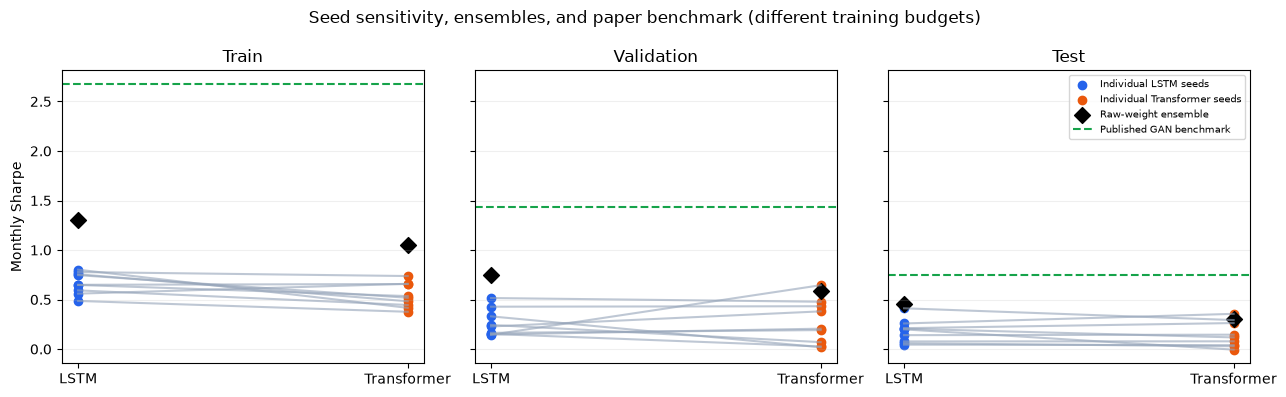

### How to interpret this comparison

The Transformer exceeds its same-numbered LSTM seed on test Sharpe in **4 of 9 seed pairs**. Pairing seed numbers is a descriptive convenience: different architectures consume random draws differently. Seed dispersion measures initialization sensitivity on one market history, not independent market evidence or a confidence interval.

The ensemble Sharpe is calculated from averaged raw stock weights, followed by monthly gross normalization. It is **not the average of the nine individual Sharpe ratios**. Diversification across members can improve the ensemble even when individual members perform weakly.

The new LSTM test Sharpe is 0.459; Transformer is 0.304; historical Code 07 is 0.612; published GAN is 0.750. Historical and paper comparisons mix training budgets and implementation conventions. Only the two new architectures share this experiment's budget.

The reduced 16/4/48 schedule and four-epoch checkpoint warm-up differ from the author schedule. A gap to the paper can reflect training, implementation, or tuning differences; this experiment does not identify their separate effects. Lower training Sharpe is consistent with incomplete optimization, but is not proof of its cause.

**Connection to Code 09:** fixed saved ensemble returns become rolling diagnostics. **Connection to Code 10:** the same returns are grouped by economic conditions; neither analysis retrains or selects the model.


1452

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd()
if not (ROOT / 'results').exists(): ROOT = ROOT.parent
assert (ROOT / 'results').exists()
def mdtable(df):
    d=df.copy()
    for col in d.select_dtypes(include='number'): d[col]=d[col].map(lambda x: f'{x:.3f}')
    return '| '+' | '.join(map(str,d.columns))+' |\n| '+' | '.join(['---']*len(d.columns))+' |\n'+'\n'.join('| '+' | '.join(map(str,row))+' |' for row in d.itertuples(index=False,name=None))

out=ROOT/'results/paper_matched_reduced_schedule'
members=pd.read_csv(out/'tables/member_performance.csv')
bench=pd.read_csv(out/'tables/full_short_paper_sharpe_comparison.csv').set_index('model')
seed_summary=members.groupby(['architecture','split']).monthly_sharpe.agg(['count','mean','std','min','median','max']).reset_index()
seed_summary.to_csv(out/'tables/explanation_seed_comparison.csv',index=False)
display(Markdown('### Individual seeds versus the ensemble\n\n'+mdtable(seed_summary)))
paired=members.pivot(index=['seed','split'],columns='architecture',values='monthly_sharpe').reset_index()
paired['transformer_minus_lstm']=paired.Transformer-paired.LSTM
paired.to_csv(out/'tables/explanation_paired_seed_gaps.csv',index=False)
gaps=bench.loc[['Reduced schedule LSTM','Reduced schedule Transformer','Historical Code 07 GAN–LSTM']].copy()
for split in ['train','validation','test']: gaps[split+'_gap_to_paper']=gaps[split]-bench.loc['Paper GAN–LSTM',split]
gaps.reset_index().to_csv(out/'tables/explanation_paper_gaps.csv',index=False)
display(Markdown('### Published GAN benchmark: absolute monthly Sharpe gaps\n\n'+mdtable(gaps.reset_index())))
fig,axes=plt.subplots(1,3,figsize=(13,4),sharey=True)
for ax,split in zip(axes,['train','validation','test']):
    sub=paired[paired.split==split]
    for row in sub.itertuples(): ax.plot([0,1],[row.LSTM,row.Transformer],color='#94a3b8',alpha=.6)
    ax.scatter(np.zeros(len(sub)),sub.LSTM,color='#2563eb',label='Individual LSTM seeds')
    ax.scatter(np.ones(len(sub)),sub.Transformer,color='#ea580c',label='Individual Transformer seeds')
    ax.scatter([0,1],[bench.loc['Reduced schedule LSTM',split],bench.loc['Reduced schedule Transformer',split]],marker='D',s=65,color='black',label='Raw-weight ensemble')
    ax.axhline(bench.loc['Paper GAN–LSTM',split],color='#16a34a',linestyle='--',label='Published GAN benchmark')
    ax.set_xticks([0,1],['LSTM','Transformer']);ax.set_title(split.title());ax.grid(axis='y',alpha=.2)
axes[0].set_ylabel('Monthly Sharpe');axes[-1].legend(fontsize=7)
fig.suptitle('Seed sensitivity, ensembles, and paper benchmark (different training budgets)')
fig.tight_layout();fig.savefig(out/'figures/explanation_seed_vs_ensemble.png',dpi=160);plt.show()
test=paired[paired.split=='test'];wins=int((test.transformer_minus_lstm>0).sum())
text=f'''### How to interpret this comparison

The Transformer exceeds its same-numbered LSTM seed on test Sharpe in **{wins} of 9 seed pairs**. Pairing seed numbers is a descriptive convenience: different architectures consume random draws differently. Seed dispersion measures initialization sensitivity on one market history, not independent market evidence or a confidence interval.

The ensemble Sharpe is calculated from averaged raw stock weights, followed by monthly gross normalization. It is **not the average of the nine individual Sharpe ratios**. Diversification across members can improve the ensemble even when individual members perform weakly.

The new LSTM test Sharpe is {bench.loc['Reduced schedule LSTM','test']:.3f}; Transformer is {bench.loc['Reduced schedule Transformer','test']:.3f}; historical Code 07 is {bench.loc['Historical Code 07 GAN–LSTM','test']:.3f}; published GAN is {bench.loc['Paper GAN–LSTM','test']:.3f}. Historical and paper comparisons mix training budgets and implementation conventions. Only the two new architectures share this experiment's budget.

The reduced 16/4/48 schedule and four-epoch checkpoint warm-up differ from the author schedule. A gap to the paper can reflect training, implementation, or tuning differences; this experiment does not identify their separate effects. Lower training Sharpe is consistent with incomplete optimization, but is not proof of its cause.

**Connection to Code 09:** fixed saved ensemble returns become rolling diagnostics. **Connection to Code 10:** the same returns are grouped by economic conditions; neither analysis retrains or selects the model.
'''
display(Markdown(text));(out/'explanation_addendum.md').write_text(text)
